# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, coro_utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'../data/{today}-llowfsc')
utils.make_dir(data_path)


INFO:numexpr.utils:NumExpr defaulting to 12 threads.
/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Directory '../data/20260605-llowfsc' already exists.


INFO:purepyindi2.transports:Connected to localhost:7624


Exception in thread IndiTcpClientConnection-receiver:
Traceback (most recent call last):
  File "/opt/conda/envs/km310gpu/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/opt/conda/envs/km310gpu/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/conda/envs/km310gpu/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/MagAOX-scoob-resurrector/source/purepyindi2/purepyindi2/transports.py", line 118, in _handle_inbound
    self._parser.parse(data)
  File "/opt/MagAOX-scoob-resurrector/source/purepyindi2/purepyindi2/parser.py", line 59, in parse
    self.parser.Parse(data)
  File "/home/conda/feedstock_root/build_artifacts/python-split_1744322439874/work/Modules/pyexpat.c", line 475, in EndElement
  File "/opt/MagAOX-scoob-resurrector/source/purepyindi2/purepyindi2/parser.py", line 174, in end_xml_element_handler
    element.set_fr

# Connect to the SHMIM streams.

In [56]:
reload(coro_utils)

cam_channel = 'nsv455'

coro_utils.set_cam_exp_time(0.001/4, client0, cam_name=cam_channel)

Set the nsv455 exposure time to 2.50e-04s


In [54]:
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)


Set the nsv455 gain setting to 0.0


In [4]:
coro_utils.set_cam_blacklevel(50, client0, cam_name=cam_channel)

Set the nsv455 blacklevel to 50.0


In [53]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [ ]:
reload(coro_utils)
coro_utils.home_block(client0, delay=2.0)

In [ ]:
coro_utils.move_block_out(client0)

In [ ]:
reload(coro_utils)
coro_utils.move_psf(-1, 0, client0)

In [ ]:
reload(coro_utils)
coro_utils.move_psf(0, -1, client0)

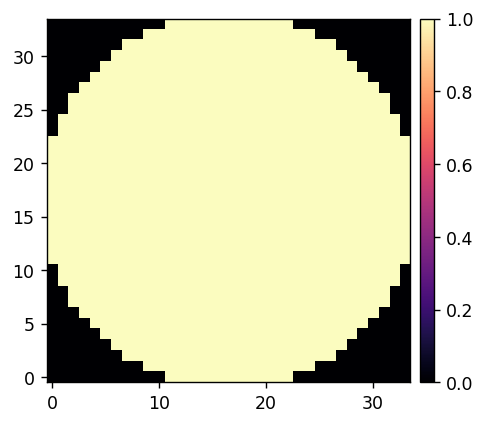

In [120]:
CAMLO_STREAM = ImageStream('nsv455')

DM_STREAMS = []
for i in range(1,11):
    DM_STREAMS.append(ImageStream(f'dm00disp{i:02}'))

rt_utils.create_shmim('llowfsc_zpo', (CAMLO_STREAM.shape[0], CAMLO_STREAM.shape[1]))
ZPO_STREAM = ImageStream('llowfsc_zpo')

rt_utils.create_shmim('llowfsc_gains', (10, 1))
GAINS_STREAM = ImageStream('llowfsc_gains')
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

Ncamlo = CAMLO_STREAM.shape[0]
Nact = DM_STREAMS[0].shape[0]

dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

In [121]:
def take_im_fun(
        CAMLO_STREAM,
        NFRAMES=1,
    ):
    camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0)
    # camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0) if NFRAMES>1 else CAMLO_STREAM.grab_after(1,0)[0]
    return camlo_im

take_im_params = {
    'CAMLO_STREAM':CAMLO_STREAM,
    'NFRAMES':1,
}

def set_dm_fun(
        command,
        DM_STREAM,
    ):

    DM_STREAM.write(1e6*ensure_np_array(command))

set_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}

def get_dm_fun(
        DM_STREAM,
    ):

    return 1e-6*DM_STREAM.grab_latest()


get_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}

def get_gains():
    return GAINS_STREAM.grab_latest()[0]

def get_zpo(ZPO_STREAM):
    return ZPO_STREAM.grab_latest()

get_zpo_params = {
    'ZPO_STREAM':ZPO_STREAM,
}

# Obtain a reference dark image for the camera settings that will be used during the duration of LLOWFSC.

In [122]:
coro_utils.move_block_in(client0)

INFO:utils:Got semaphore index 0.


Saved data to:  ../data/20260605-llowfsc/camlo_dark_0.000250s_0gain.fits


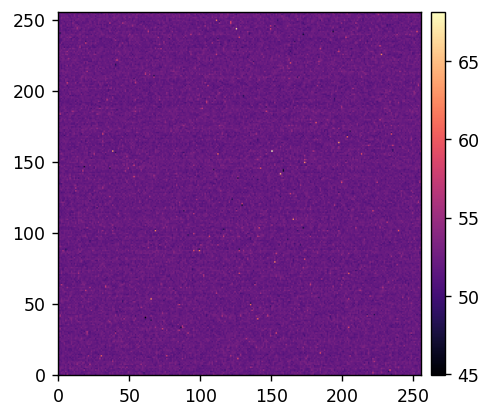

In [124]:

take_im_params.update({
    'NFRAMES':80,
})

camlo_dark = take_im_fun(**take_im_params)
exp_time = coro_utils.get_cam_exp_time(client0, cam_channel)
gain = coro_utils.get_cam_gain(client0, cam_channel)
utils.save_fits(data_path/f'camlo_dark_{exp_time:.6f}s_{gain:.0f}gain.fits', camlo_dark)

utils.imshow([camlo_dark])

In [125]:
coro_utils.move_block_out(client0)

# Obtain the reference image.

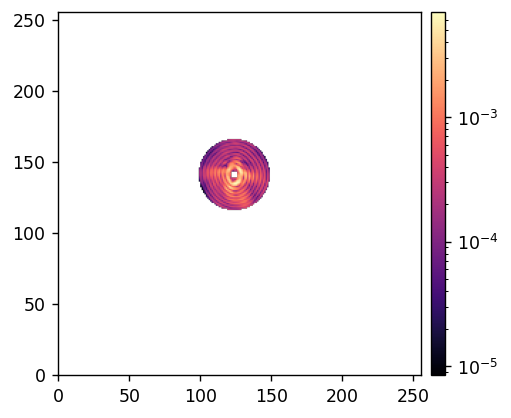

In [126]:
reload(llowfsc)

irad = 2.5
orad = 25
wfs_mask = utils.create_annular_mask(
    CAMLO_STREAM.shape[0], 
    irad, 
    orad, 
    1,
    edge=None, 
    x_shift=-4,
    y_shift=13,
    return_np=1,
)

take_im_params.update({
    'NFRAMES':80,
})

ref_im, flux_norm_coeff = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    camlo_dark=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im],
    norms=[LogNorm()] 
)


In [21]:
lina.__file__

'/home/kianmilani/Projects/lina/lina/__init__.py'

# Calibrate for the set of Zernike modes that we want to control.

Calibrated mode 1/10 in 0.997s

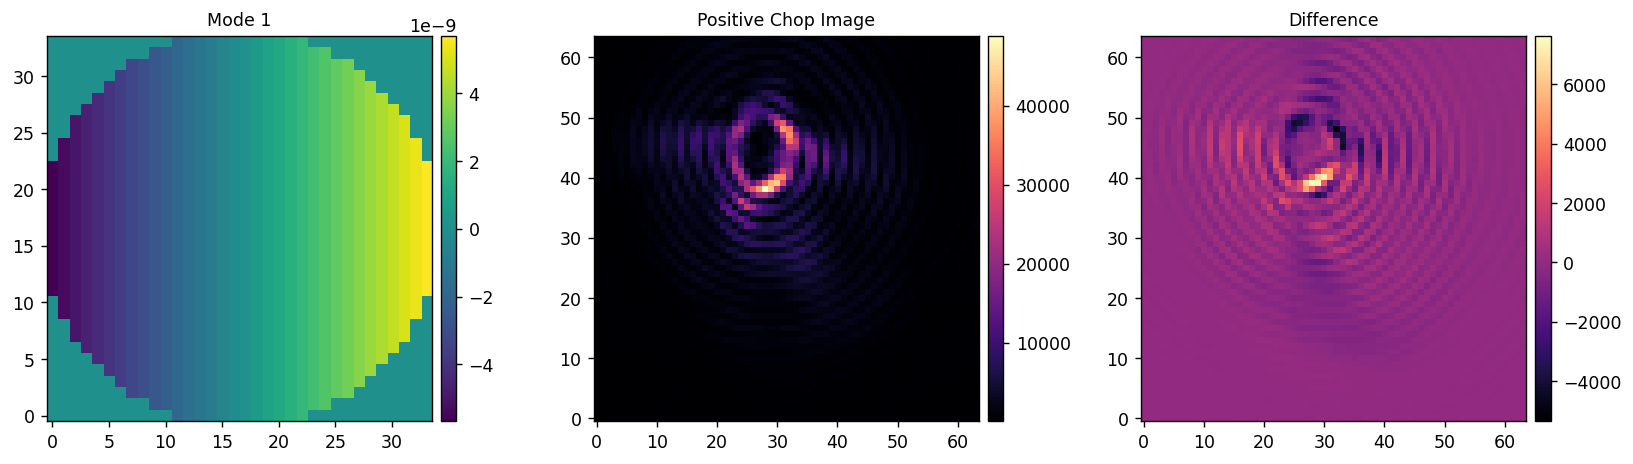

Calibrated mode 2/10 in 2.827s

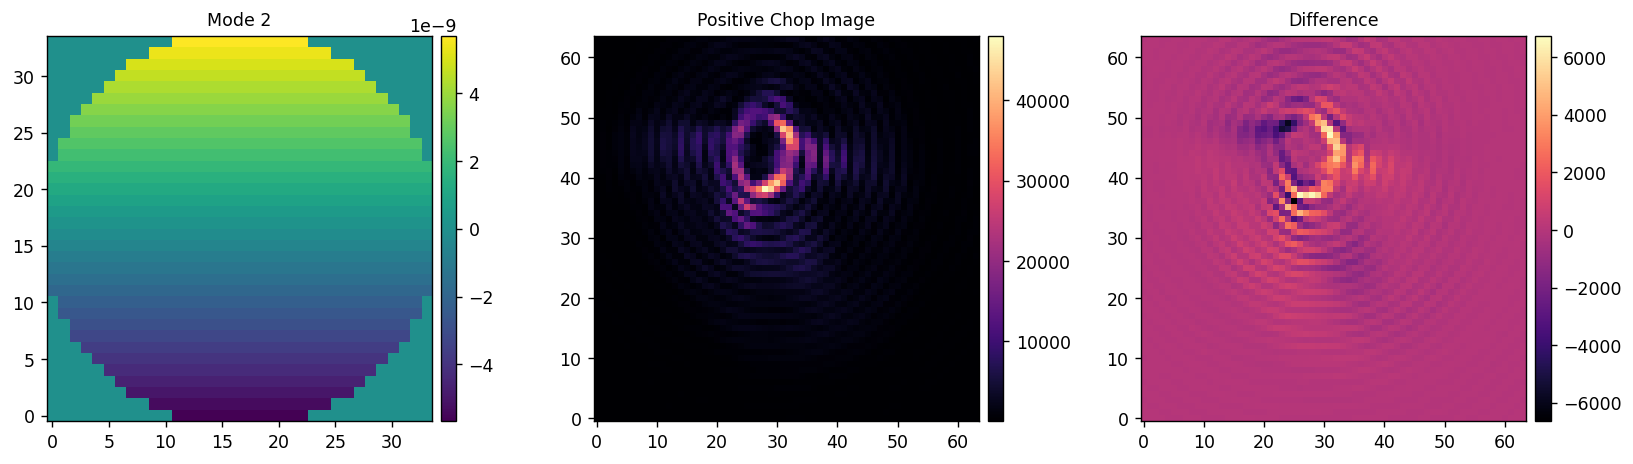

Calibrated mode 3/10 in 4.469s

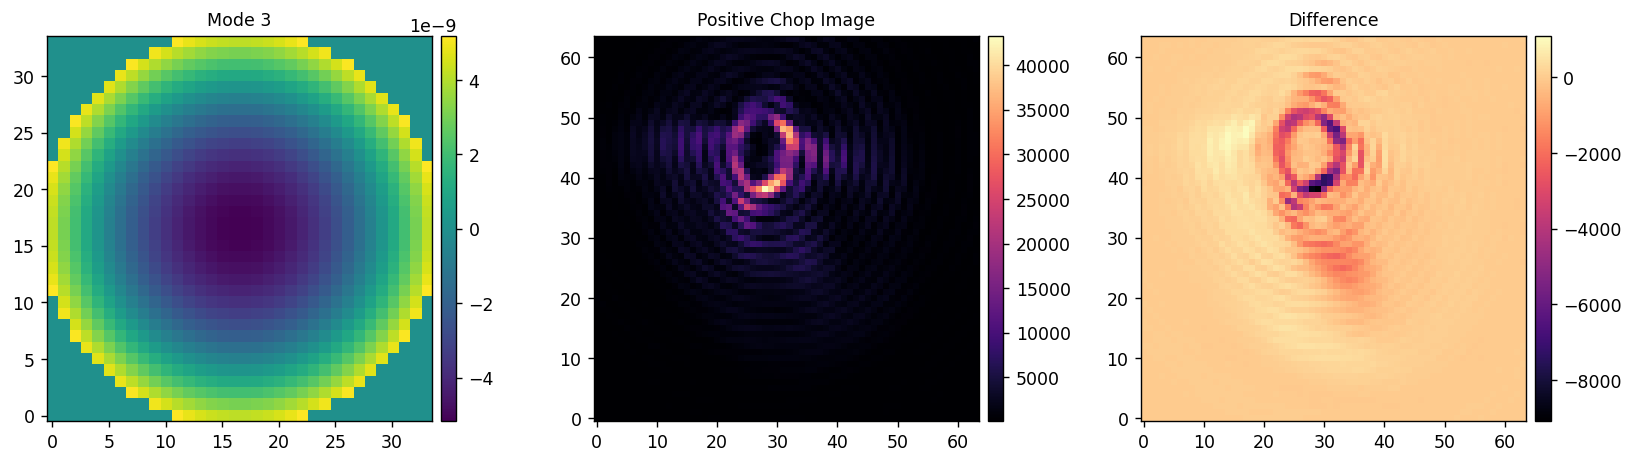

Calibrated mode 4/10 in 6.273s

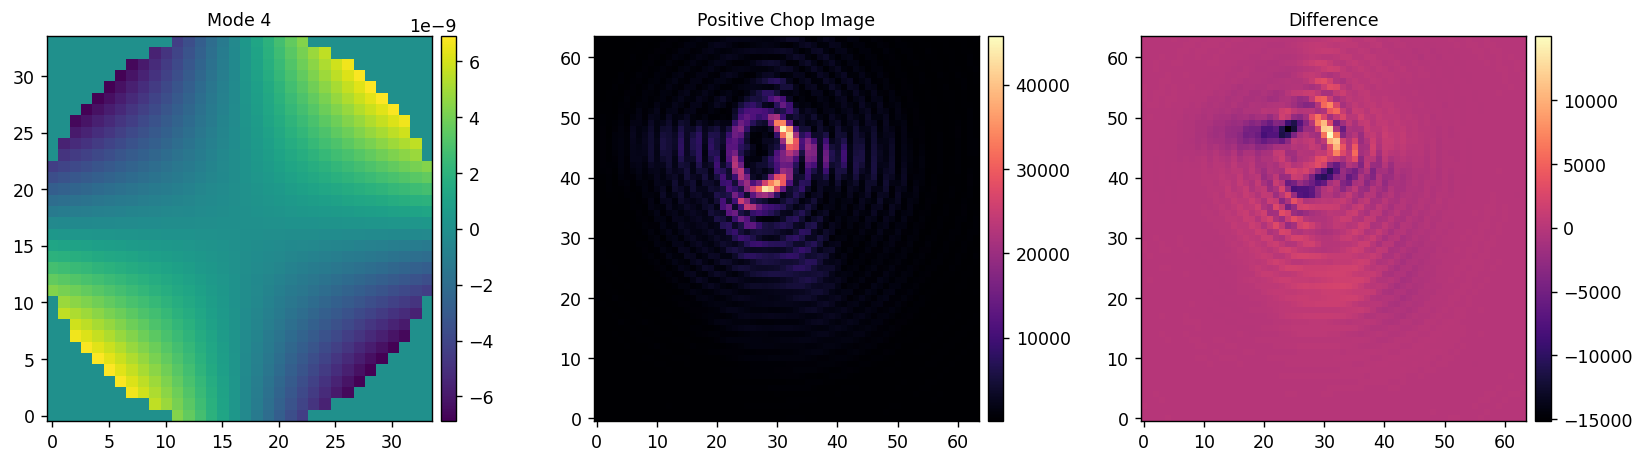

Calibrated mode 5/10 in 8.105s

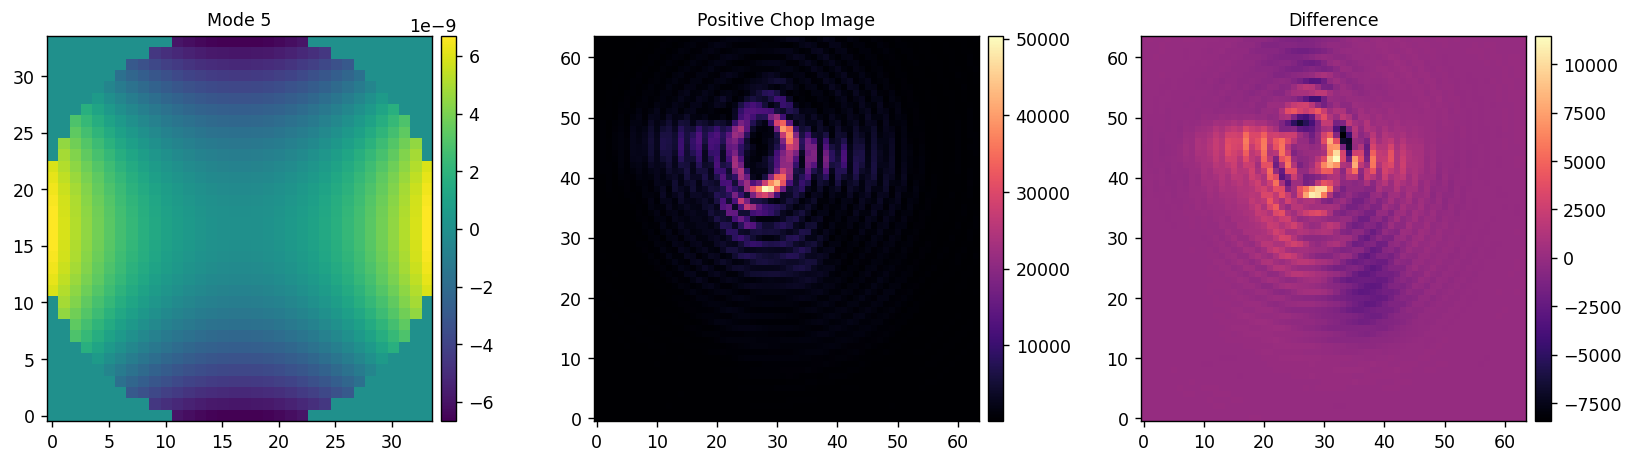

Calibrated mode 6/10 in 10.210s

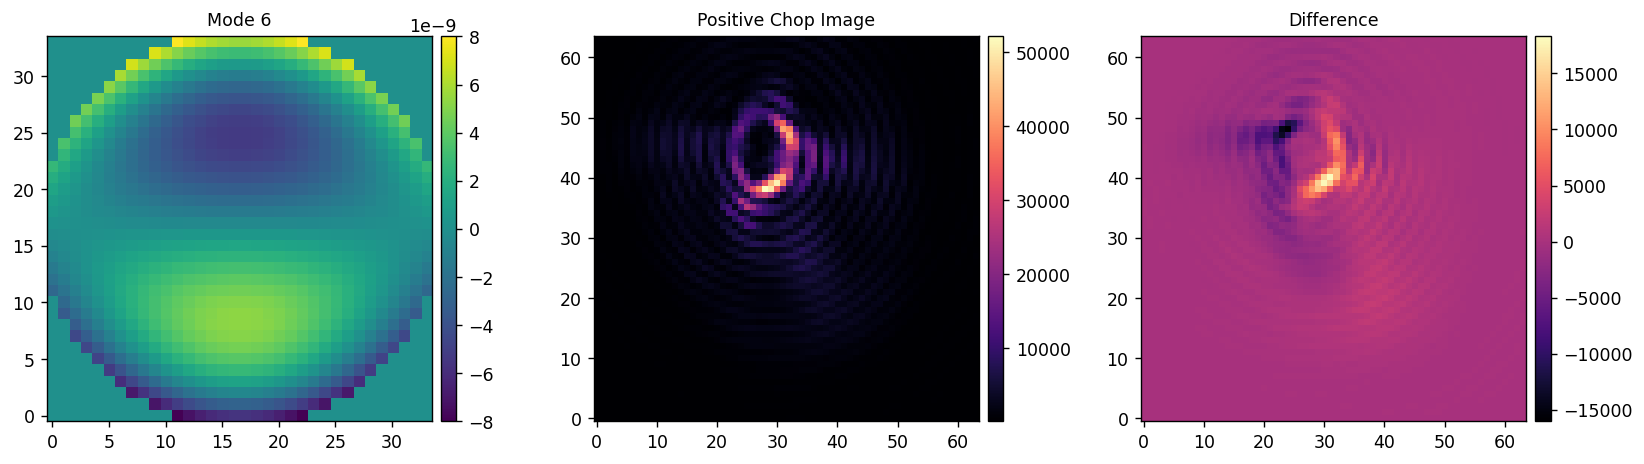

Calibrated mode 7/10 in 12.157s

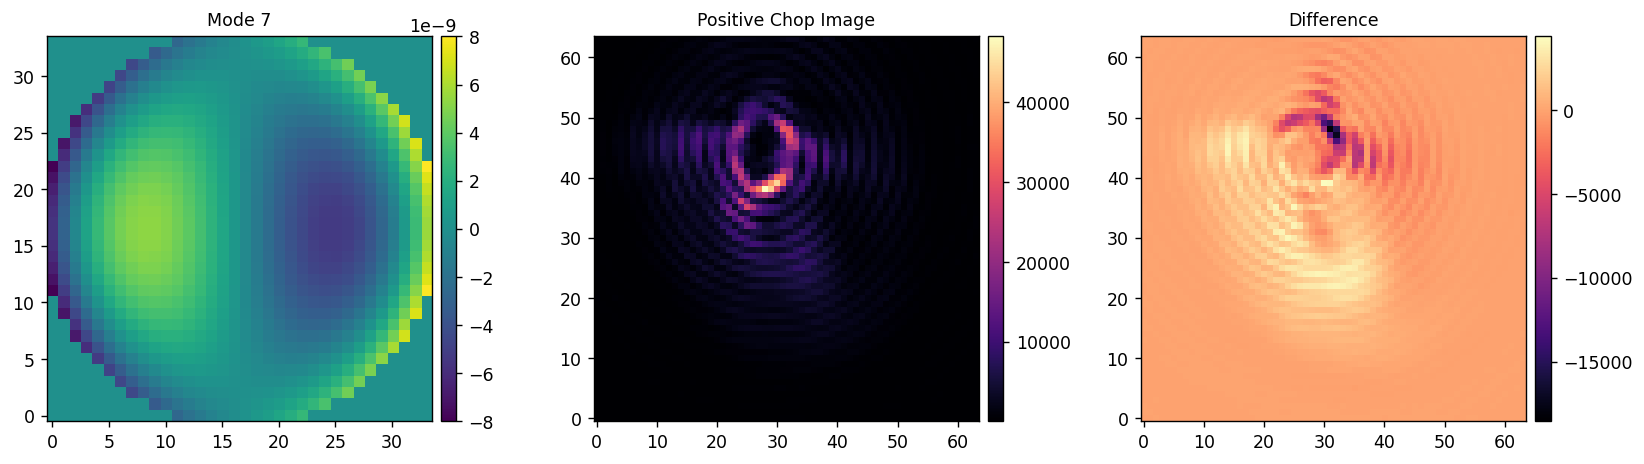

Calibrated mode 8/10 in 14.052s

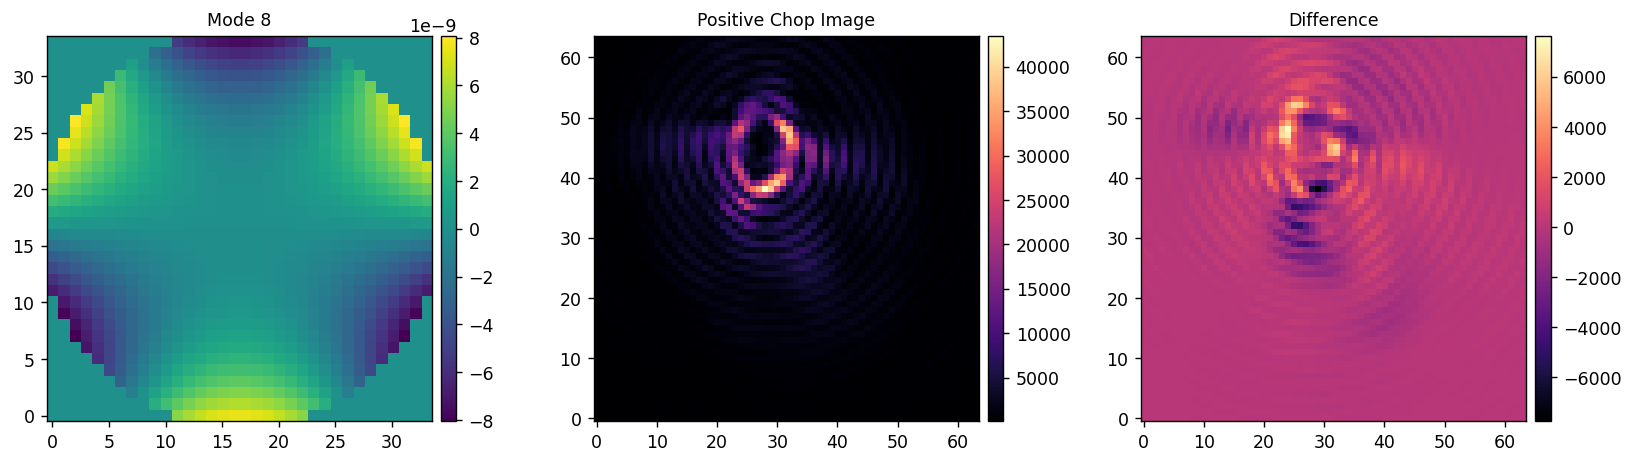

Calibrated mode 9/10 in 15.834s

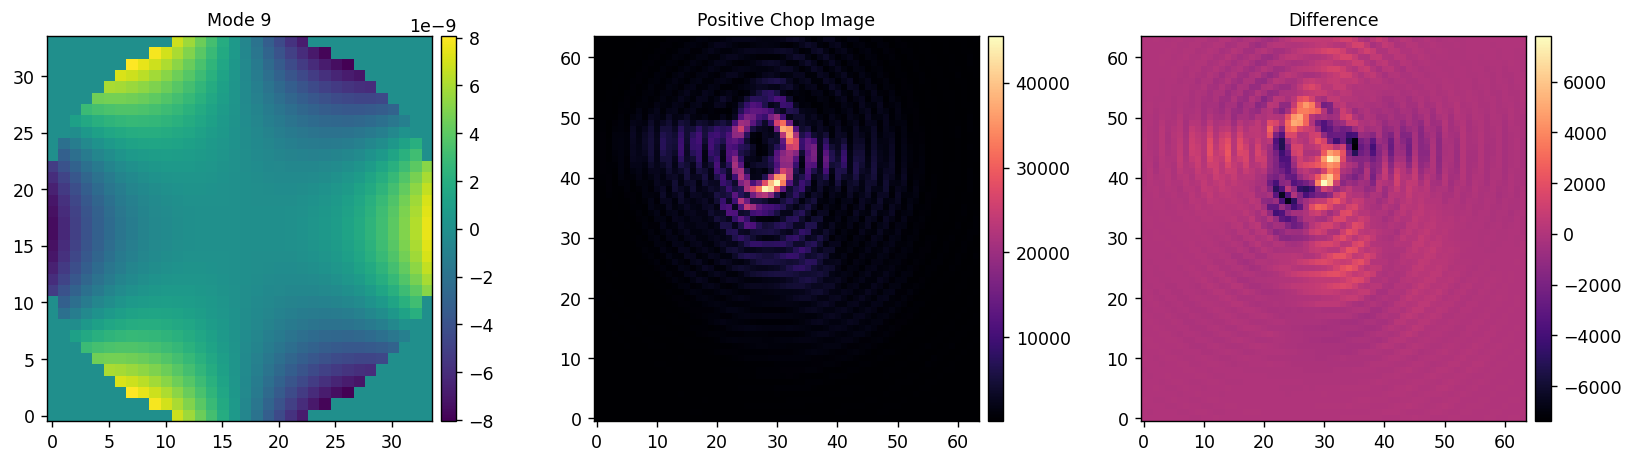

Calibrated mode 10/10 in 17.828s

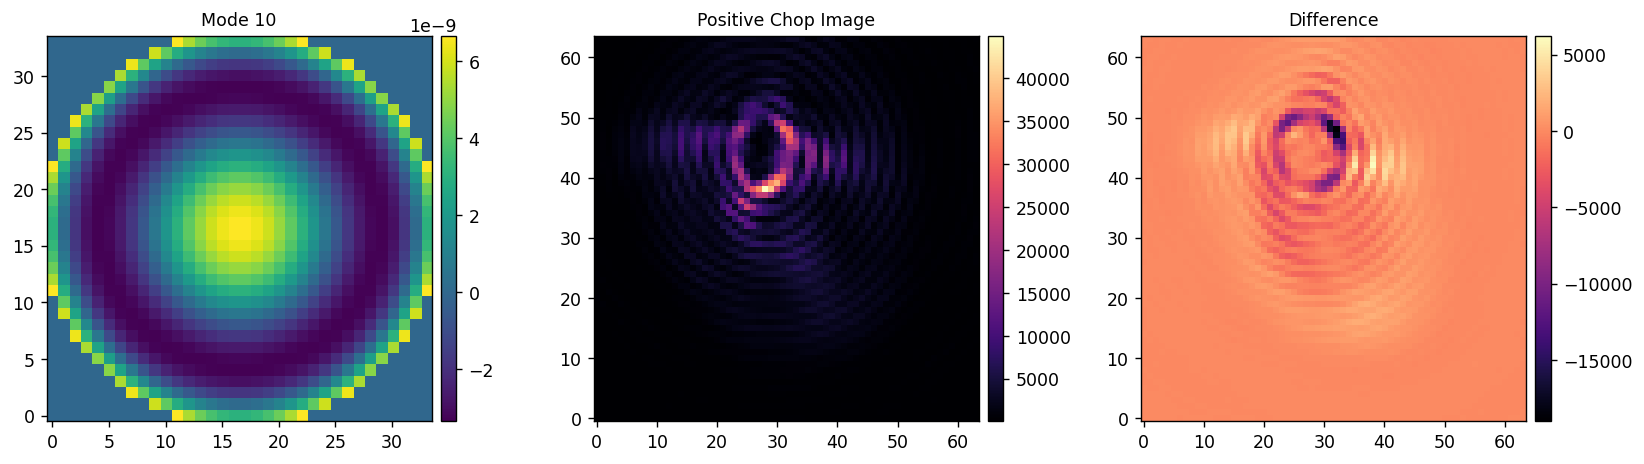

In [127]:
reload(llowfsc)
reload(dm)
reload(utils)

Nmodes = 10

dm_zer_mask = utils.pad_or_crop(dm.create_mask(Nact=Nact, return_np=1), DM_STREAMS[0].shape[0])
dm_zernike_modes = dm.create_zernike_modes(dm_zer_mask, nmodes=Nmodes, remove_modes=1, return_np=1)
# utils.imshow([dm_zernike_modes[0], dm_zernike_modes[3], dm_zernike_modes[-1]], cmaps=3*['viridis'])

take_im_params.update({
    'NFRAMES':20,
})

zer_rm, zer_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_zernike_modes, 
    wfs_mask, 
    amp=3e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    plot=True,
    npix=64,
)


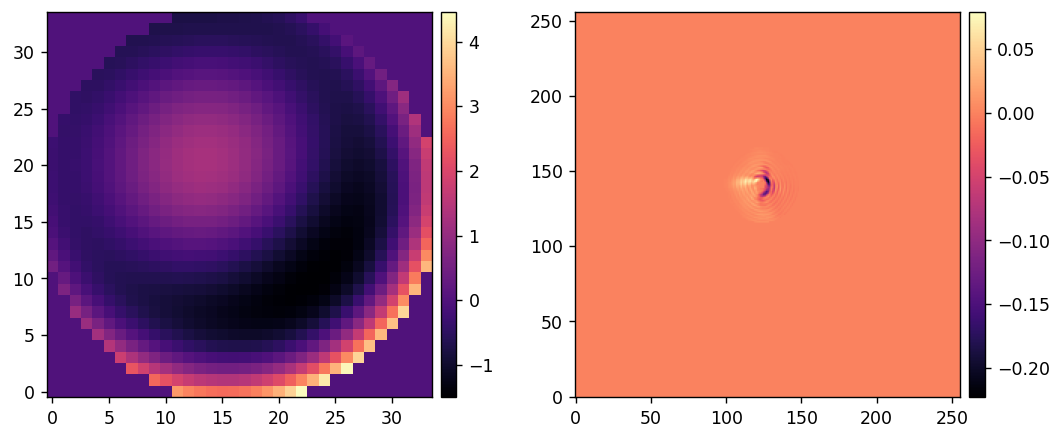

In [108]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(zer_rm, 0, return_all=1, return_np=1)

dm_modes = np.zeros((Nmodes, Nact, Nact))
wfs_modes = np.zeros((Nmodes, Ncamlo, Ncamlo))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(dm_zernike_modes[:, dm_mask])[i]
    # dm_modes[i, dm_mask] = Vt.T.dot(dm_zernike_modes[:, dm_mask])[i]
    wfs_modes[i, wfs_mask] = U.T[i] 

# dm_modes = Vt.dot(dm_zernike_modes[:, dm_mask])
# wfs_modes = U.T

# dm_modes.shape

i = 0
utils.imshow(
    [dm_modes[i], wfs_modes[i]]
)

# Start the LLOWFSC process

In [143]:
reload(rt_utils)

take_im_params.update({
    'NFRAMES':1,
})

llowfsc_proc = rt_utils.ContinuousProcess(
    llowfsc.run,
    args=[
        take_im_fun,
        take_im_params,
        set_dm_fun,
        set_dm_params,
        get_dm_fun,
        get_dm_params,
        get_gains,
        ref_im,
        P,
        dm_zernike_modes,
        wfs_mask,
    ],
    kwargs={
        'dark_im':camlo_dark,
        'get_zpo':get_zpo,
        'get_zpo_params':get_zpo_params,
    },
)

In [144]:
llowfsc_proc.start()

UNNAMED process started. PID = 3108055


In [145]:
llowfsc_proc.stop()
set_dm_fun(np.zeros_like(dm_mask), **set_dm_params)

UNNAMED process terminated.


In [134]:
rt_utils.write(GAINS_STREAM, np.array(2*[0.9] + 8*[0.3]))

# Setup the ZPO process

In [130]:
def compute_zpo(
        DM_STREAMS,
        dm_mask,
        wfs_mask,
        response_matrix,
        dm_modal_matrix,
        ZPO_STREAM,
    ):
    zpo = np.zeros((wfs_mask.shape[0], wfs_mask.shape[1]))
    for i in range(len(DM_STREAMS)):
        zpo[wfs_mask] += response_matrix.dot( dm_modal_matrix.dot(1e-6*DM_STREAMS[i].grab_latest()[dm_mask]) )

    ZPO_STREAM.write(zpo)

zpo_params = {
    # 'DM_STREAMS':DM_STREAMS[1:],
    'DM_STREAMS':[DM_STREAMS[1]],
    'dm_mask':dm_mask,
    'wfs_mask':wfs_mask,
    'response_matrix':zer_rm, 'dm_modal_matrix':dm_zernike_modes[:, dm_mask]/952 ,
    # 'response_matrix':had_rm, 'dm_modal_matrix':dm_had_modes[:, dm_mask]/1024,
    'ZPO_STREAM':ZPO_STREAM,
}

In [114]:
set_dm_fun(0e-9 * dm_zernike_modes[2], DM_STREAMS[1])

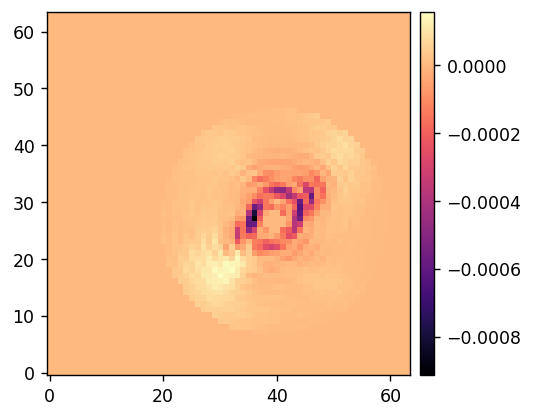

In [42]:
compute_zpo(**zpo_params)

zpo = ZPO_STREAM.grab_latest()

utils.imshow(
    [zpo]
)

In [34]:
%%timeit -n 1000
zpo = compute_zpo(**zpo_params)

276 μs ± 45.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [131]:
reload(rt_utils)
zpo_freq = 500

zpo_process = rt_utils.TimedThread(
    1/zpo_freq,
    compute_zpo,
    kwargs=zpo_params,
)

In [132]:
zpo_process.start()

In [146]:
zpo_process.cancel()

In [117]:
set_dm_fun(3e-9 * dm_zernike_modes[8], DM_STREAMS[1])

In [118]:
set_dm_fun(0e-9 * dm_zernike_modes[8], DM_STREAMS[1])